In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Configuración visual para gráficos estilo "publicación académica"
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "serif"
})

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


In [3]:
# Carga directa desde el archivo generado por el benchmark
csv_filename = "benchmark_granular_workflow.csv"

try:
    df = pd.read_csv(csv_filename)
    print(f"✅ Archivo '{csv_filename}' cargado exitosamente.")
    print(f"📊 Total de registros analizados: {len(df)}")
    
    # Separar los perfiles en Python y C++ para análisis específicos
    df_py = df[df['perfil'].isin(['seq', 'par', 'weights'])].copy()
    df_cpp = df[df['perfil'].str.startswith('cpp_')].copy()
    
    # Mostrar un resumen de los datos cargados
    display(df.head())
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{csv_filename}'.")
    print("Asegúrate de que el notebook esté en la misma carpeta que el CSV o ajusta la ruta.")

✅ Archivo 'benchmark_granular_workflow.csv' cargado exitosamente.
📊 Total de registros analizados: 600


,sample,n_nets,perfil,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
0,1,10,seq,0.852186,0.001338,0.314229,1.167753,169.507812,10.533203,361.578125,361.578125,38,68,1024
1,1,10,par,0.460802,0.043698,0.493096,0.997597,544.858398,50.521484,1044.702148,1044.702148,38,68,1024
2,1,10,weights,0.434926,0.035109,0.442846,0.912881,180.832031,38.020508,545.189453,545.189453,38,68,1024
3,1,10,cpp_seq,0.011063,0.000088,0.015481,0.026653,51.437500,1.375000,130.046875,182.859375,38,68,1024
4,1,10,cpp_par,0.006126,0.000047,0.014321,0.023855,55.812500,1.750000,128.343750,185.906250,38,68,1024


In [4]:
# Verificamos que para cada 'sample', el número de atractores, pares y campos sea idéntico en todos los perfiles
integrity_check = df.groupby('sample')[['n_attractors', 'n_pairs', 'n_fields']].nunique()

is_consistent = (integrity_check == 1).all().all()

if is_consistent:
    print("✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.")
else:
    print("❌ ADVERTENCIA: Hay discrepancias en los resultados topológicos entre los perfiles.")
    display(integrity_check[integrity_check > 1].dropna())

✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.


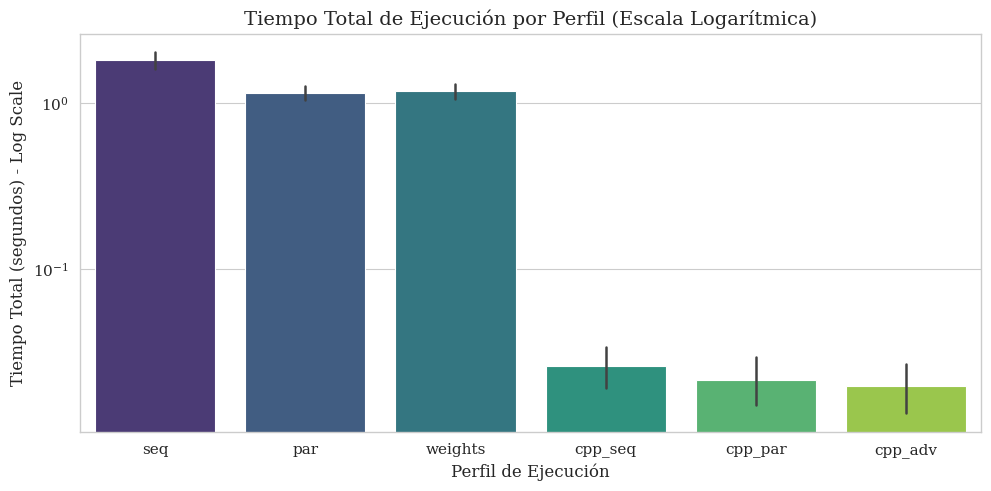

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='perfil', y='total_t', hue='perfil', palette='viridis', legend=False, ax=ax)
ax.set_title("Tiempo Total de Ejecución por Perfil (Escala Logarítmica)")
ax.set_ylabel("Tiempo Total (segundos) - Log Scale")
ax.set_xlabel("Perfil de Ejecución")
ax.set_yscale("log") # Usamos escala logarítmica porque la diferencia es inmensa

plt.tight_layout()
plt.show()

In [6]:
# Calcular los promedios de tiempo para cada perfil (robusto ante múltiples muestras)
t_py_seq = df.loc[df['perfil'] == 'seq', 'total_t'].mean()
t_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'total_t'].mean()

t_py_par = df.loc[df['perfil'] == 'par', 'total_t'].mean()
t_cpp_par = df.loc[df['perfil'] == 'cpp_par', 'total_t'].mean()

# En Python el paralelo avanzado es 'weights', en C++ es 'cpp_adv'
t_py_adv = df.loc[df['perfil'] == 'weights', 'total_t'].mean()
t_cpp_adv = df.loc[df['perfil'] == 'cpp_adv', 'total_t'].mean()

# Cálculos de Speedup (Evitando división por cero por si algún dato falta)
speedup_seq = (t_py_seq / t_cpp_seq) if t_cpp_seq > 0 else 0
speedup_par = (t_py_par / t_cpp_par) if t_cpp_par > 0 else 0
speedup_adv = (t_py_adv / t_cpp_adv) if t_cpp_adv > 0 else 0

print("=== 🚀 ANÁLISIS DE SPEEDUP (PYTHON VS C++) ===")

print("\n--- 1. Comparativa Secuencial (Un hilo) ---")
print(f"⏱️ Python 'seq':      {t_py_seq:.6f} s")
print(f"⏱️ C++ 'cpp_seq':     {t_cpp_seq:.6f} s")
print(f"🔥 Speedup:           C++ es {speedup_seq:.2f}x más rápido")

print("\n--- 2. Comparativa Paralela (Estándar) ---")
print(f"⏱️ Python 'par':      {t_py_par:.6f} s")
print(f"⏱️ C++ 'cpp_par':     {t_cpp_par:.6f} s")
print(f"🔥 Speedup:           C++ es {speedup_par:.2f}x más rápido")

print("\n--- 3. Comparativa Avanzada (Heurísticas/Weights) ---")
print(f"⏱️ Python 'weights':  {t_py_adv:.6f} s")
print(f"⏱️ C++ 'cpp_adv':     {t_cpp_adv:.6f} s")
print(f"🔥 Speedup:           C++ es {speedup_adv:.2f}x más rápido")

=== 🚀 ANÁLISIS DE SPEEDUP (PYTHON VS C++) ===

--- 1. Comparativa Secuencial (Un hilo) ---
⏱️ Python 'seq':      1.798892 s
⏱️ C++ 'cpp_seq':     0.025845 s
🔥 Speedup:           C++ es 69.60x más rápido

--- 2. Comparativa Paralela (Estándar) ---
⏱️ Python 'par':      1.141796 s
⏱️ C++ 'cpp_par':     0.021467 s
🔥 Speedup:           C++ es 53.19x más rápido

--- 3. Comparativa Avanzada (Heurísticas/Weights) ---
⏱️ Python 'weights':  1.168818 s
⏱️ C++ 'cpp_adv':     0.019540 s
🔥 Speedup:           C++ es 59.82x más rápido


In [15]:
# Celda 10: Análisis de Eficiencia de Espacio (Python vs C++)

# Calcular los promedios de memoria total (mem_total_kb) para cada perfil
mem_py_seq = df.loc[df['perfil'] == 'seq', 'mem_total_kb'].mean()
mem_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'mem_total_kb'].mean()

mem_py_par = df.loc[df['perfil'] == 'par', 'mem_total_kb'].mean()
mem_cpp_par = df.loc[df['perfil'] == 'cpp_par', 'mem_total_kb'].mean()

mem_py_adv = df.loc[df['perfil'] == 'weights', 'mem_total_kb'].mean()
mem_cpp_adv = df.loc[df['perfil'] == 'cpp_adv', 'mem_total_kb'].mean()

# Cálculos de Sobrecarga (Overhead). Manejamos la división por cero por seguridad.
overhead_seq = (mem_py_seq / mem_cpp_seq) if mem_cpp_seq > 0 else float('inf')
overhead_par = (mem_py_par / mem_cpp_par) if mem_cpp_par > 0 else float('inf')
overhead_adv = (mem_py_adv / mem_cpp_adv) if mem_cpp_adv > 0 else float('inf')

print("=== 🧠 ANÁLISIS DE EFICIENCIA DE ESPACIO (PYTHON VS C++) ===")
print("Métrica: Factor de Sobrecarga (Cuántas veces más memoria requiere Python)")

print("\n--- 1. Comparativa Secuencial (Un hilo) ---")
print(f"📦 Python 'seq':      {mem_py_seq:.2f} KB")
print(f"📦 C++ 'cpp_seq':     {mem_cpp_seq:.2f} KB")
if mem_cpp_seq > 0:
    print(f"📉 Sobrecarga:        Python consume {overhead_seq:.2f}x veces más memoria")
else:
    print("📉 Sobrecarga:        N/A (C++ reporta 0 KB)")

print("\n--- 2. Comparativa Paralela (Estándar) ---")
print(f"📦 Python 'par':      {mem_py_par:.2f} KB")
print(f"📦 C++ 'cpp_par':     {mem_cpp_par:.2f} KB")
if mem_cpp_par > 0:
    print(f"📉 Sobrecarga:        Python consume {overhead_par:.2f}x veces más memoria")

print("\n--- 3. Comparativa Avanzada (Heurísticas/Weights) ---")
print(f"📦 Python 'weights':  {mem_py_adv:.2f} KB")
print(f"📦 C++ 'cpp_adv':     {mem_cpp_adv:.2f} KB")
if mem_cpp_adv > 0:
    print(f"📉 Sobrecarga:        Python consume {overhead_adv:.2f}x veces más memoria")

# Análisis de Penalización por Paralelismo
print("\n--- ⚠️ PENALIZACIÓN DE MEMORIA POR MULTIPROCESAMIENTO ---")
penalidad_py = (mem_py_par / mem_py_seq) if mem_py_seq > 0 else 0
penalidad_cpp = (mem_cpp_par / mem_cpp_seq) if mem_cpp_seq > 0 else 0
print(f"Al cambiar de Secuencial a Paralelo:")
print(f"🐍 Python infla su memoria en: {penalidad_py:.2f}x")
print(f"⚙️ C++ infla su memoria en:    {penalidad_cpp:.2f}x")

=== 🧠 ANÁLISIS DE EFICIENCIA DE ESPACIO (PYTHON VS C++) ===
Métrica: Factor de Sobrecarga (Cuántas veces más memoria requiere Python)

--- 1. Comparativa Secuencial (Un hilo) ---
📦 Python 'seq':      478.00 KB
📦 C++ 'cpp_seq':     190.24 KB
📉 Sobrecarga:        Python consume 2.51x veces más memoria

--- 2. Comparativa Paralela (Estándar) ---
📦 Python 'par':      976.74 KB
📦 C++ 'cpp_par':     190.04 KB
📉 Sobrecarga:        Python consume 5.14x veces más memoria

--- 3. Comparativa Avanzada (Heurísticas/Weights) ---
📦 Python 'weights':  773.72 KB
📦 C++ 'cpp_adv':     153.21 KB
📉 Sobrecarga:        Python consume 5.05x veces más memoria

--- ⚠️ PENALIZACIÓN DE MEMORIA POR MULTIPROCESAMIENTO ---
Al cambiar de Secuencial a Paralelo:
🐍 Python infla su memoria en: 2.04x
⚙️ C++ infla su memoria en:    1.00x


/tmp/ipykernel_12512/2089487719.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/carlos/projects/cbn_core/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 69.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_12512/2089487719.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/carlos/projects/cbn_core/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 68.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_12512/2089487719.

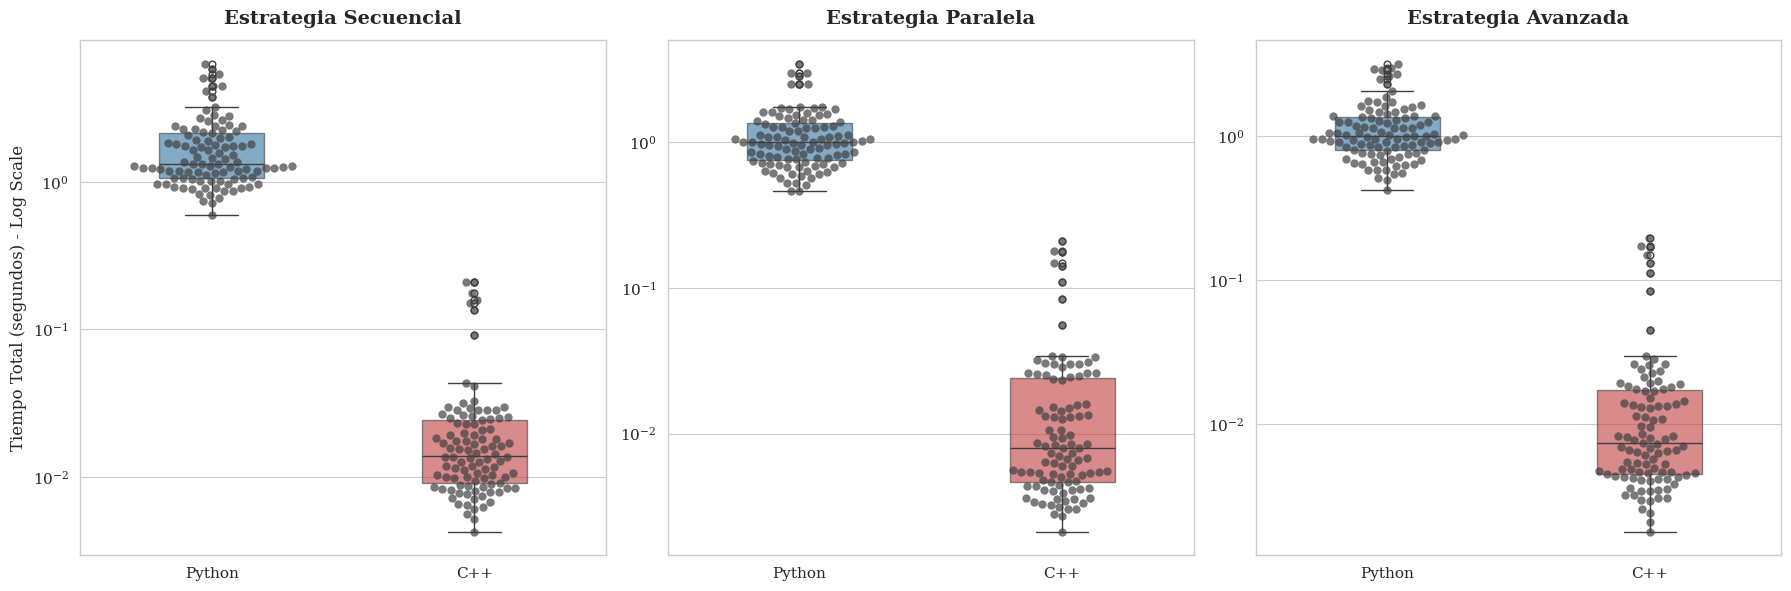

In [18]:
# Celda 5 (Vista en Paralelo): Distribución de Tiempos Totales (C++ vs Python)

# Definimos los combates
pares_comparativos = [
    ('Estrategia Secuencial', ['cpp_seq', 'seq']),
    ('Estrategia Paralela', ['cpp_par', 'par']),
    ('Estrategia Avanzada', ['cpp_adv', 'weights'])
]

# Crear figura con 1 fila y 3 columnas (en paralelo)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (titulo, perfiles) in enumerate(pares_comparativos):
    # Filtrar datos del combate actual
    df_combate = df[df['perfil'].isin(perfiles)].copy()
    
    # Crear etiqueta limpia para C++ vs Python
    df_combate['Lenguaje'] = df_combate['perfil'].apply(
        lambda x: 'C++' if x.startswith('cpp_') else 'Python'
    )
    
    # BOXPLOT: Orientado verticalmente (x=Lenguaje, y=Tiempo)
    sns.boxplot(
        data=df_combate, 
        x='Lenguaje', 
        y='total_t', 
        ax=axes[i], 
        palette={'C++': '#d62728', 'Python': '#1f77b4'}, 
        width=0.4,
        boxprops=dict(alpha=0.6)
    )
    
    # SWARMPLOT: Puntos individuales superpuestos
    sns.swarmplot(
        data=df_combate, 
        x='Lenguaje', 
        y='total_t', 
        ax=axes[i], 
        color=".25", 
        size=6, 
        alpha=0.7
    )
    
    # Configuración de ejes y títulos
    axes[i].set_title(titulo, fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel('')
    
    # Escala logarítmica en Y para manejar la diferencia de velocidad
    axes[i].set_yscale('log')
    
    # Solo mostrar la etiqueta del eje Y en el primer gráfico para mayor limpieza visual
    if i == 0:
        axes[i].set_ylabel('Tiempo Total (segundos) - Log Scale', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

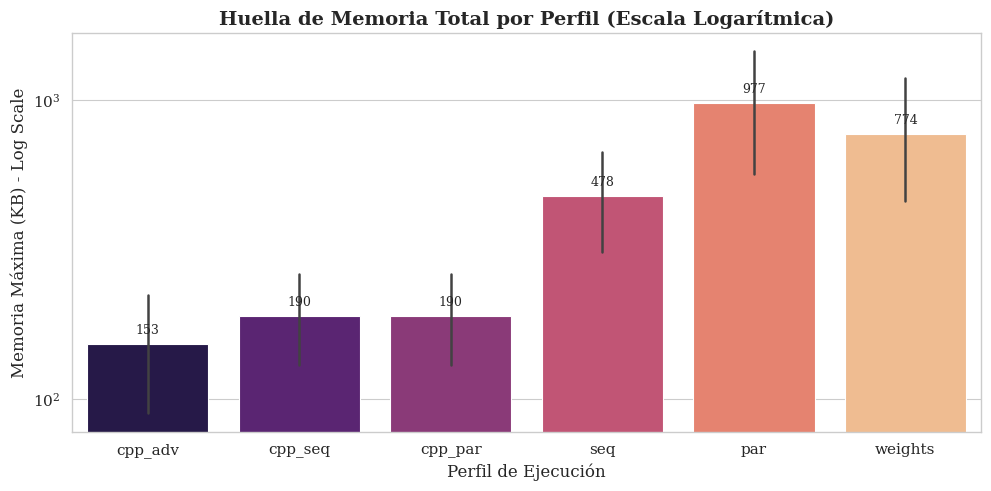

In [19]:
# Celda 6: Análisis de Memoria (Diagnóstico del OOM)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Comparativa de Memoria Máxima (Total) con Escala Logarítmica
fig, ax1 = plt.subplots(figsize=(10, 5))

# Ordenamos de menor a mayor para mejor lectura
df_sorted_mem = df.sort_values('mem_total_kb')

sns.barplot(
    data=df_sorted_mem, 
    x='perfil', 
    y='mem_total_kb', 
    hue='perfil', 
    palette='magma', 
    legend=False, 
    ax=ax1
)
ax1.set_title("Huella de Memoria Total por Perfil (Escala Logarítmica)", fontweight='bold')
ax1.set_ylabel("Memoria Máxima (KB) - Log Scale")
ax1.set_xlabel("Perfil de Ejecución")
ax1.set_yscale('log') # CRUCIAL para ver las barras de C++

# Añadir valores numéricos encima de las barras
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{p.get_height():.0f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=9, xytext=(0, 5), 
                     textcoords='offset points')

plt.tight_layout()
plt.savefig("memoria_total_comparativa.pdf", format='pdf', bbox_inches='tight') # Para LuaLaTeX
plt.show()

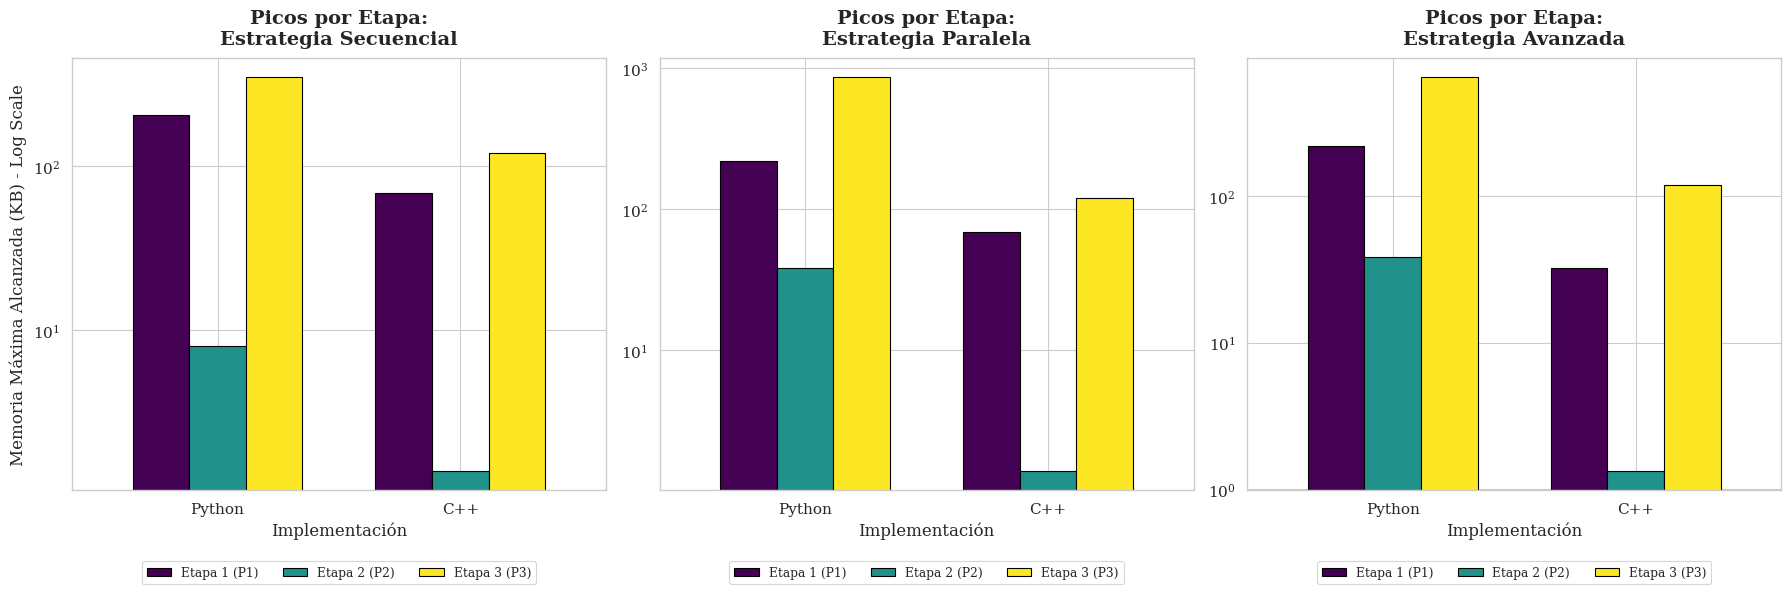

=== 🔍 DIAGNÓSTICO DE CUELLOS DE BOTELLA (MEMORIA) ===
🚨 La etapa que genera mayor presión de RAM en Python es: P3 (Promedio: 616.65 KB)
   -> Al ver el gráfico, notarás la caída masiva de memoria al pasar a C++ en esta misma etapa.


In [22]:
# 2. Desglose de Memoria Interna por Etapas (Python vs C++)
import matplotlib.pyplot as plt
import numpy as np

# Definimos los combates (pares a comparar)
pares_comparativos = [
    ('Estrategia Secuencial', ['seq', 'cpp_seq']),
    ('Estrategia Paralela', ['par', 'cpp_par']),
    ('Estrategia Avanzada', ['weights', 'cpp_adv'])
]

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (titulo, perfiles) in enumerate(pares_comparativos):
    # Filtrar datos del combate actual
    df_par = df[df['perfil'].isin(perfiles)].copy()
    
    # Agrupar por perfil y promediar las etapas de memoria
    df_mem = df_par.groupby('perfil')[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].mean().reset_index()
    
    # Crear etiqueta limpia para el eje X
    df_mem['Lenguaje'] = df_mem['perfil'].apply(lambda x: 'C++' if x.startswith('cpp_') else 'Python')
    
    # ORDENAR: Python primero (izquierda), luego C++ (derecha)
    # Al poner ascending=False, "Python" se coloca antes que "C++"
    df_mem = df_mem.sort_values(by='Lenguaje', ascending=False).set_index('Lenguaje')
    
    # Graficar barras AGRUPADAS (stacked=False)
    df_mem.plot(
        kind='bar', 
        ax=axes[i], 
        colormap='viridis', 
        edgecolor='black', 
        width=0.7,
        stacked=False 
    )
    
    axes[i].set_title(f"Picos por Etapa:\n{titulo}", fontweight='bold', pad=10)
    axes[i].set_xlabel("Implementación")
    axes[i].tick_params(axis='x', rotation=0)
    
    # Escala logarítmica OBLIGATORIA
    axes[i].set_yscale('log')
    
    if i == 0:
        axes[i].set_ylabel("Memoria Máxima Alcanzada (KB) - Log Scale")
    else:
        axes[i].set_ylabel("")
        
    # Colocar la leyenda debajo para no estorbar visualmente la caída de memoria
    axes[i].legend(["Etapa 1 (P1)", "Etapa 2 (P2)", "Etapa 3 (P3)"], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Añadir espacio extra en la parte inferior para que la leyenda no se corte al exportar
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.savefig("memoria_desglose_comparativo.pdf", format='pdf', bbox_inches='tight') # Listo para tu documento LuaLaTeX
plt.show()

# Análisis textual automatizado
print("=== 🔍 DIAGNÓSTICO DE CUELLOS DE BOTELLA (MEMORIA) ===")
py_p1 = df[df['perfil'].isin(['seq', 'par', 'weights'])]['mem_p1_kb'].mean()
py_p2 = df[df['perfil'].isin(['seq', 'par', 'weights'])]['mem_p2_kb'].mean()
py_p3 = df[df['perfil'].isin(['seq', 'par', 'weights'])]['mem_p3_kb'].mean()

max_stage_val = max(py_p1, py_p2, py_p3)
if max_stage_val == py_p1: etapa_critica = "P1"
elif max_stage_val == py_p2: etapa_critica = "P2"
else: etapa_critica = "P3"

print(f"🚨 La etapa que genera mayor presión de RAM en Python es: {etapa_critica} (Promedio: {max_stage_val:.2f} KB)")
print("   -> Al ver el gráfico, notarás la caída masiva de memoria al pasar a C++ en esta misma etapa.")

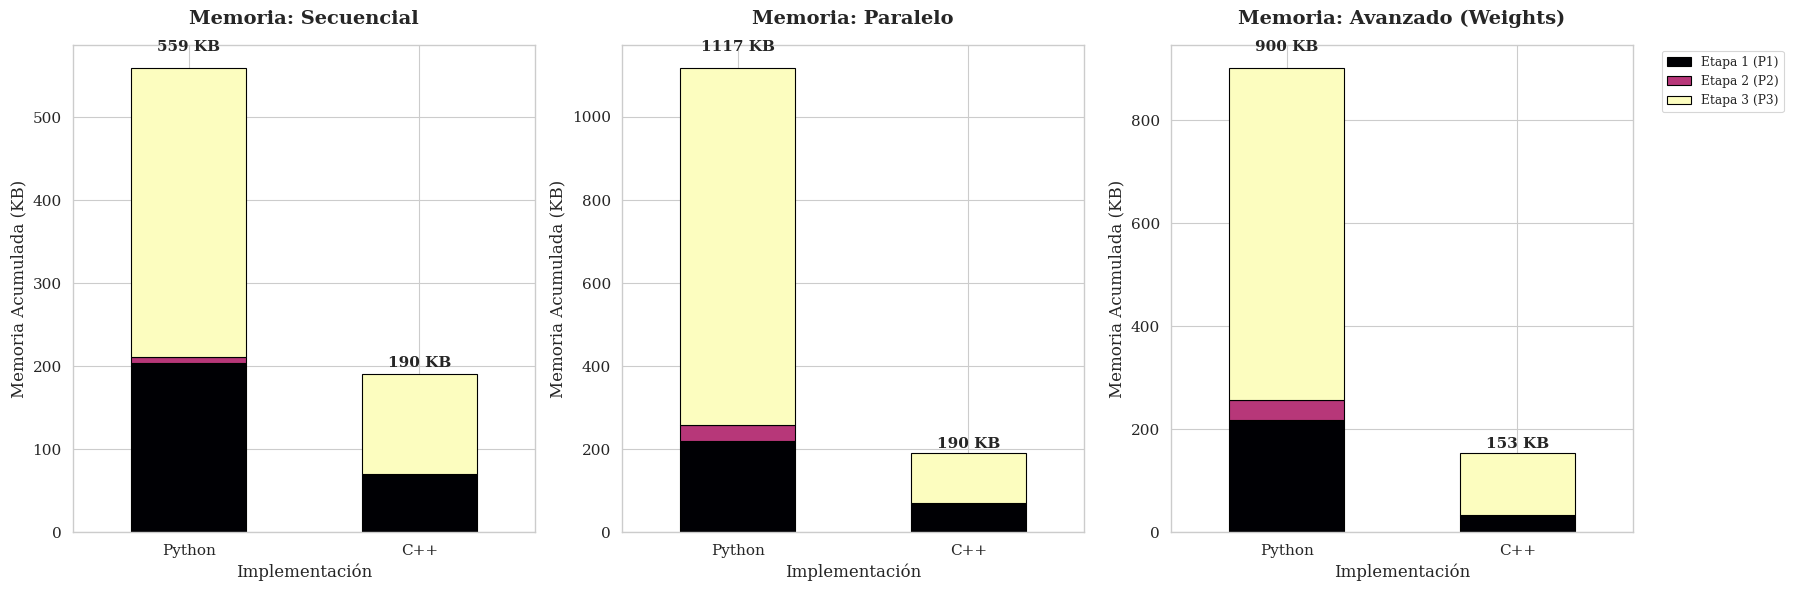

In [23]:
# Celda 6 (Actualizada y Mejorada): Comparativa Directa de Memoria Apilada (Python vs C++)
import matplotlib.pyplot as plt

# Definimos los pares exactos que queremos comparar (Python primero, C++ segundo en los nombres no importa, 
# el código lo ordenará alfabéticamente a la inversa)
pares_comparativos = [
    ('Secuencial', ['seq', 'cpp_seq']),
    ('Paralelo', ['par', 'cpp_par']),
    ('Avanzado (Weights)', ['weights', 'cpp_adv'])
]

# Crear una figura con 3 subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (titulo, perfiles) in enumerate(pares_comparativos):
    # Filtrar solo los datos de los 2 perfiles que compiten en este round
    df_par = df[df['perfil'].isin(perfiles)].copy()
    
    # Agrupar por perfil y promediar las etapas de memoria
    df_mean = df_par.groupby('perfil')[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].mean().reset_index()
    
    # Crear la columna de lenguaje para facilitar la lectura del gráfico
    df_mean['Lenguaje'] = df_mean['perfil'].apply(
        lambda x: 'C++' if x.startswith('cpp_') else 'Python'
    )
    
    # ORDENAR: Python primero (izquierda), luego C++ (derecha)
    # ascending=False asegura que la "P" de Python vaya antes que la "C" de C++
    df_mean = df_mean.sort_values(by='Lenguaje', ascending=False).set_index('Lenguaje')
    
    # Graficar las barras apiladas (stacked=True)
    # Usamos la paleta 'magma' que contrasta muy bien en documentos académicos impresos
    df_mean[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].plot(
        kind='bar', stacked=True, ax=axes[i], colormap='magma', edgecolor='black'
    )
    
    axes[i].set_title(f"Memoria: {titulo}", fontweight='bold', pad=15)
    axes[i].set_ylabel("Memoria Acumulada (KB)")
    axes[i].set_xlabel("Implementación")
    axes[i].tick_params(axis='x', rotation=0)
    
    # Magia para la calidad de la documentación: Añadir el valor total encima de cada barra
    for j, (idx, row) in enumerate(df_mean.iterrows()):
        # La altura total de la barra apilada es la suma de sus partes
        total_apilado = row['mem_p1_kb'] + row['mem_p2_kb'] + row['mem_p3_kb']
        
        # Ajustar ligeramente la altura del texto para que no se superponga con la barra
        # Usamos :.0f para mostrar KB enteros y no saturar el gráfico con decimales
        axes[i].text(j, total_apilado + (total_apilado * 0.03), f"{total_apilado:.0f} KB", 
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Solo mostrar la leyenda en el último gráfico para no saturar la imagen
    if i == 2:
        axes[i].legend(["Etapa 1 (P1)", "Etapa 2 (P2)", "Etapa 3 (P3)"], 
                       loc='upper left', bbox_to_anchor=(1.05, 1))
    else:
        axes[i].legend().remove()

# Ajustar márgenes para que los números y leyendas no se corten
plt.tight_layout()
plt.savefig("memoria_apilada_python_vs_cpp.pdf", format='pdf', bbox_inches='tight') # Vectorial para LuaLaTeX
plt.show()

/tmp/ipykernel_12512/205959732.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


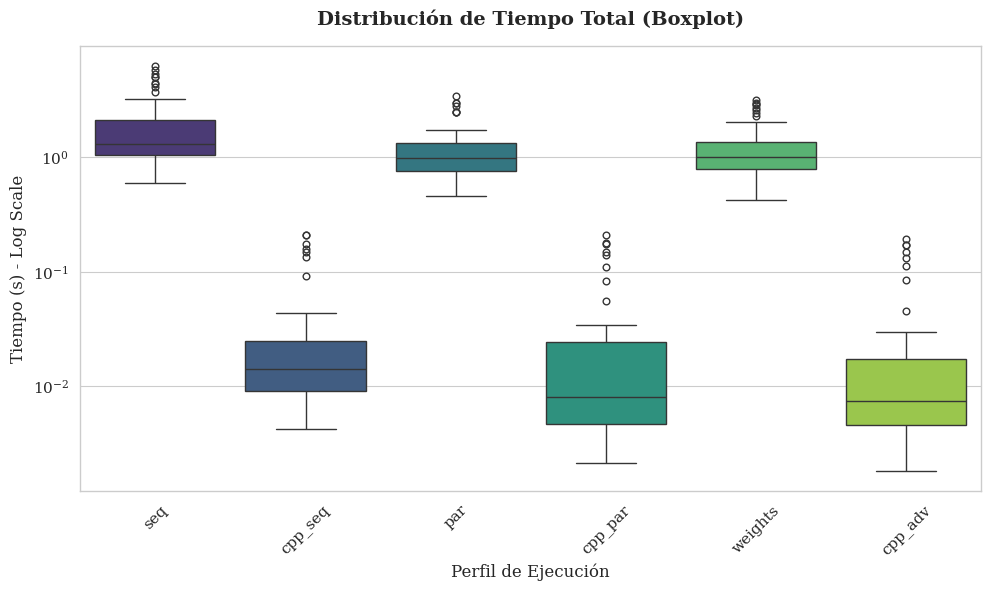

In [25]:
# Celda 7: Análisis de Tiempo Total (Boxplot Python vs C++)
import matplotlib.pyplot as plt
import seaborn as sns

# Garantizamos el orden visual: Python (lento) seguido de C++ (rápido)
orden_perfiles = ['seq', 'cpp_seq', 'par', 'cpp_par', 'weights', 'cpp_adv']

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='perfil', 
    y='total_t', 
    order=orden_perfiles, 
    ax=ax, 
    palette='viridis'
)

ax.set_title('Distribución de Tiempo Total (Boxplot)', fontweight='bold', pad=15)
ax.set_ylabel('Tiempo (s) - Log Scale')
ax.set_xlabel('Perfil de Ejecución')
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

# Exportación vectorial para el documento
plt.tight_layout()
plt.savefig("boxplot_tiempo.pdf", format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_12512/964036997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


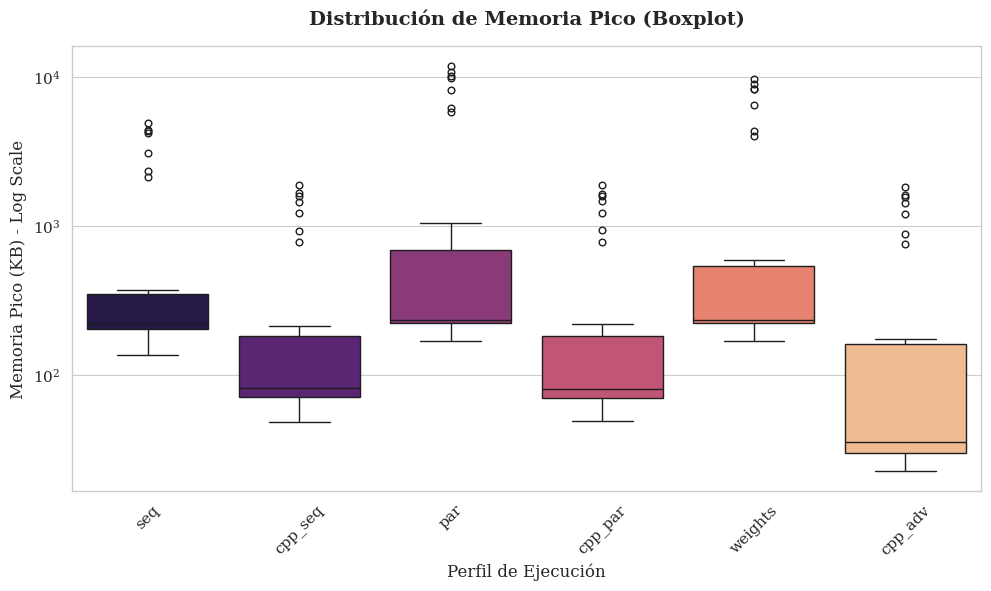

In [27]:
# Celda 8 (Corregida): Análisis de Memoria Pico (Boxplot Python vs C++)
import matplotlib.pyplot as plt
import seaborn as sns

# Garantizamos el orden visual: Python (pesado) seguido de C++ (ligero)
orden_perfiles = ['seq', 'cpp_seq', 'par', 'cpp_par', 'weights', 'cpp_adv']

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='perfil', 
    y='mem_total_kb', 
    order=orden_perfiles, 
    ax=ax, 
    palette='magma'
)

ax.set_title('Distribución de Memoria Pico (Boxplot)', fontweight='bold', pad=15)
ax.set_ylabel('Memoria Pico (KB) - Log Scale') # Texto corregido
ax.set_xlabel('Perfil de Ejecución')

# LA SOLUCIÓN: Cambiamos 'symlog' por 'log' estándar
ax.set_yscale('log') 

ax.tick_params(axis='x', rotation=45)

# Exportación vectorial para el documento
plt.tight_layout()
plt.savefig("boxplot_memoria.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [28]:
# Celda 8: Análisis Estadístico Descriptivo

print("=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===")
# Agrupamos por perfil y calculamos métricas clave
time_stats = df.groupby('perfil')['total_t'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos de más lento a más rápido
time_stats = time_stats.sort_values(by='Media', ascending=False)
display(time_stats.style.format("{:.6f}", na_rep="-").background_gradient(cmap='Blues'))

print("\n=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===")
mem_stats = df.groupby('perfil')['mem_total_kb'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos del que consume más memoria al que menos
mem_stats = mem_stats.sort_values(by='Media', ascending=False)
display(mem_stats.style.format("{:.2f}", na_rep="-").background_gradient(cmap='Reds'))

=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
seq,100.000000,1.798892,1.161798,1.320858,0.598864,6.278377
weights,100.000000,1.168818,0.581678,1.001972,0.421943,3.164523
par,100.000000,1.141796,0.578859,0.995572,0.463842,3.439360
cpp_seq,100.000000,0.025845,0.039590,0.013948,0.004234,0.210579
cpp_par,100.000000,0.021467,0.038242,0.007967,0.002108,0.209464
cpp_adv,100.000000,0.019540,0.036665,0.007429,0.001794,0.194893



=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
par,100.00,976.74,2298.83,232.58,167.32,11820.09
weights,100.00,773.72,1853.37,232.65,169.16,9715.00
seq,100.00,478.00,911.25,223.96,135.59,4917.67
cpp_seq,100.00,190.24,340.95,81.12,48.42,1886.30
cpp_par,100.00,190.04,339.78,80.15,48.91,1875.02
cpp_adv,100.00,153.21,342.36,35.25,22.50,1840.70


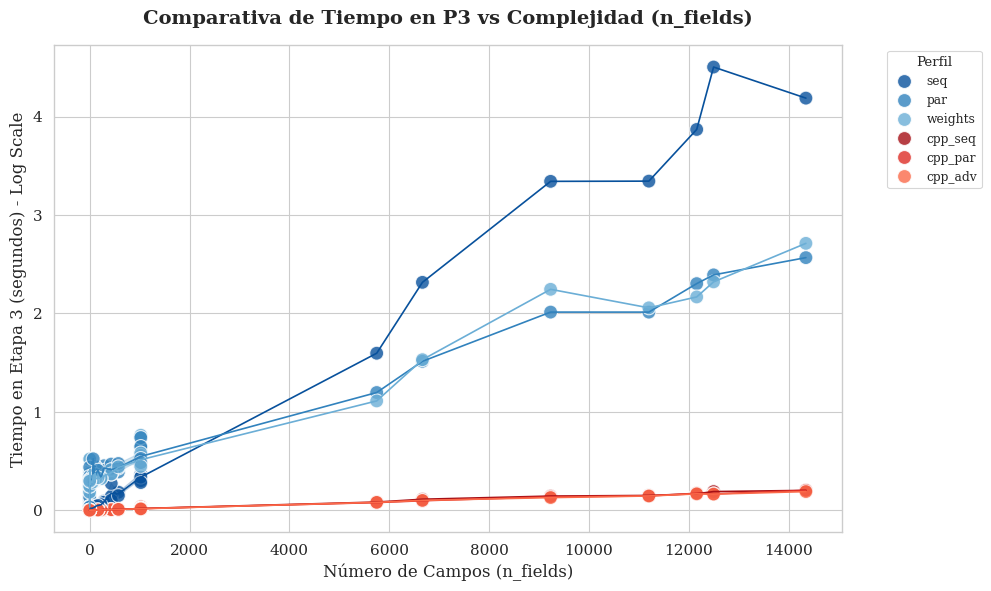

In [31]:
# Celda 9a: Relación de Complejidad vs Tiempo en la Etapa 3 (P3)
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta personalizada: Azules para Python, Rojos/Naranjas para C++
paleta_perfiles = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de dispersión (puntos) y líneas de tendencia
sns.scatterplot(data=df, x='n_fields', y='t_p3', hue='perfil', palette=paleta_perfiles, s=100, alpha=0.8, ax=ax)
sns.lineplot(data=df, x='n_fields', y='t_p3', hue='perfil', palette=paleta_perfiles, legend=False, ax=ax)

ax.set_title('Comparativa de Tiempo en P3 vs Complejidad (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Tiempo en Etapa 3 (segundos) - Log Scale')
ax.set_xlabel('Número de Campos (n_fields)')

# Escala logarítmica crucial para ver la tendencia de C++ sin que se aplane en el eje X
# ax.set_yscale('log') 

# Ajustar la leyenda fuera del gráfico
plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("complejidad_vs_tiempo_p3.pdf", format='pdf', bbox_inches='tight')
plt.show()

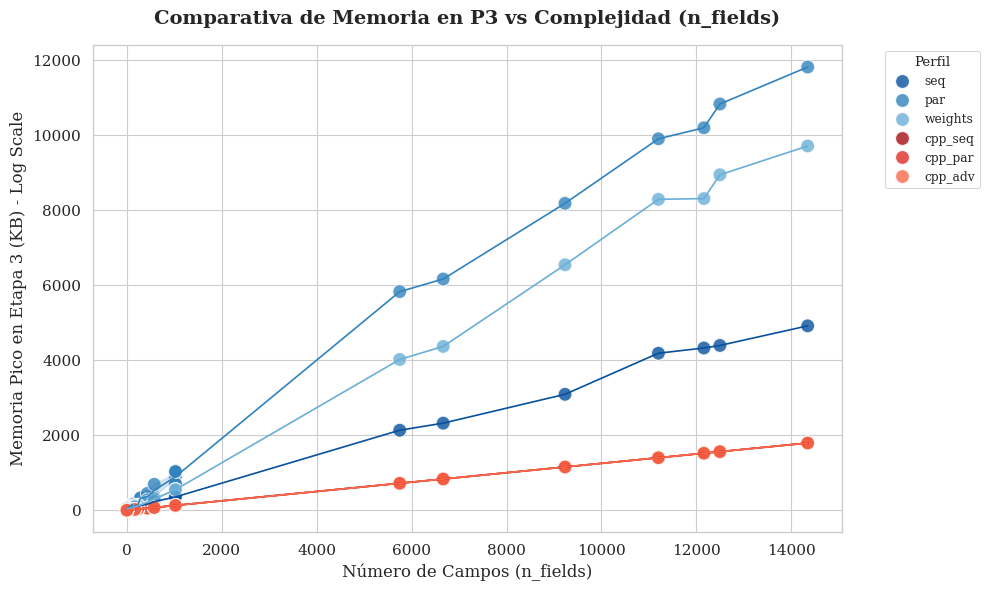


=== 📈 CORRELACIÓN (PEARSON) CON n_fields EN LA ETAPA 3 ===

🐍 PYTHON:
  • Correlación n_fields vs Tiempo P3:  0.9344
  • Correlación n_fields vs Memoria P3: 0.9407

⚙️ C++:
  • Correlación n_fields vs Tiempo P3:  0.9969
  • Correlación n_fields vs Memoria P3: 1.0000


In [32]:
# Celda 9b: Relación de Complejidad vs Memoria en la Etapa 3 (P3) y Correlación
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos la misma paleta para mantener la consistencia visual
paleta_perfiles = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='n_fields', y='mem_p3_kb', hue='perfil', palette=paleta_perfiles, s=100, alpha=0.8, ax=ax)
sns.lineplot(data=df, x='n_fields', y='mem_p3_kb', hue='perfil', palette=paleta_perfiles, legend=False, ax=ax)

ax.set_title('Comparativa de Memoria en P3 vs Complejidad (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Memoria Pico en Etapa 3 (KB) - Log Scale')
ax.set_xlabel('Número de Campos (n_fields)')
#ax.set_yscale('log')

plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("complejidad_vs_memoria_p3.pdf", format='pdf', bbox_inches='tight')
plt.show()

# --- ANÁLISIS DE CORRELACIÓN ---
print("\n=== 📈 CORRELACIÓN (PEARSON) CON n_fields EN LA ETAPA 3 ===")

print("\n🐍 PYTHON:")
# Usamos el DataFrame filtrado de Python (df_py) para aislar las métricas
if df_py['n_fields'].nunique() > 1:
    corr_py_t = df_py['n_fields'].corr(df_py['t_p3'])
    corr_py_m = df_py['n_fields'].corr(df_py['mem_p3_kb'])
    print(f"  • Correlación n_fields vs Tiempo P3:  {corr_py_t:.4f}")
    print(f"  • Correlación n_fields vs Memoria P3: {corr_py_m:.4f}")
else:
    print("  • Ejecuta el benchmark con múltiples topologías para calcular la correlación.")

print("\n⚙️ C++:")
# Usamos el DataFrame filtrado de C++ (df_cpp)
if df_cpp['n_fields'].nunique() > 1:
    corr_cpp_t = df_cpp['n_fields'].corr(df_cpp['t_p3'])
    corr_cpp_m = df_cpp['n_fields'].corr(df_cpp['mem_p3_kb'])
    print(f"  • Correlación n_fields vs Tiempo P3:  {corr_cpp_t:.4f}")
    print(f"  • Correlación n_fields vs Memoria P3: {corr_cpp_m:.4f}")
else:
    print("  • Ejecuta el benchmark con múltiples topologías para calcular la correlación.")

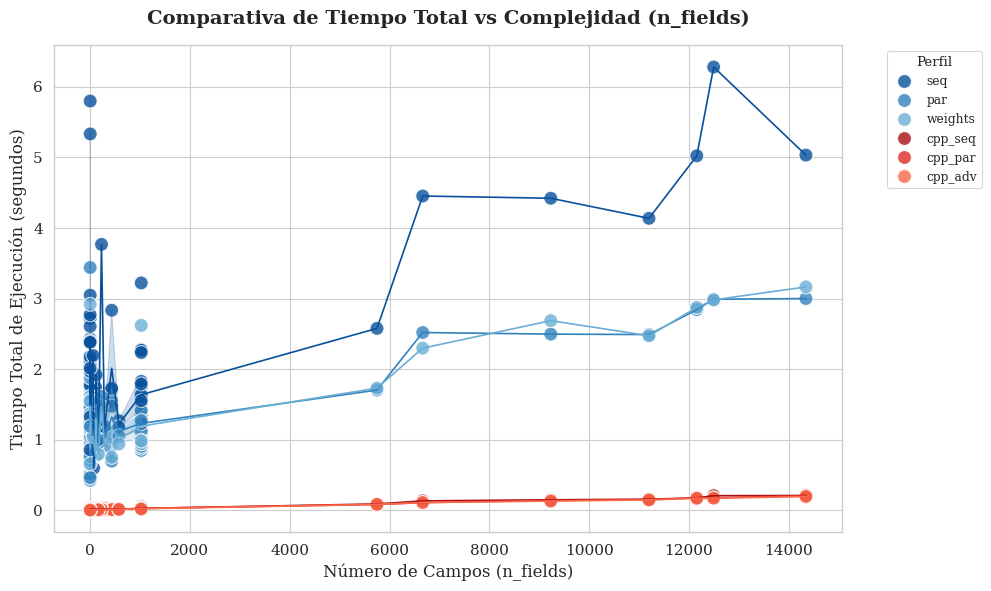

In [33]:
# Celda 10a: Relación de Complejidad (n_fields) vs Tiempo Total (total_t)
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta unificada: Azules para Python, Rojos para C++
paleta_perfiles = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de dispersión y líneas de tendencia con escala lineal (simple)
sns.scatterplot(data=df, x='n_fields', y='total_t', hue='perfil', palette=paleta_perfiles, s=100, alpha=0.8, ax=ax)
sns.lineplot(data=df, x='n_fields', y='total_t', hue='perfil', palette=paleta_perfiles, legend=False, ax=ax)

ax.set_title('Comparativa de Tiempo Total vs Complejidad (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Tiempo Total de Ejecución (segundos)')
ax.set_xlabel('Número de Campos (n_fields)')

# Leyenda lateral limpia
plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')

# Exportación vectorial para LuaLaTeX
plt.tight_layout()
plt.savefig("complejidad_vs_tiempo_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

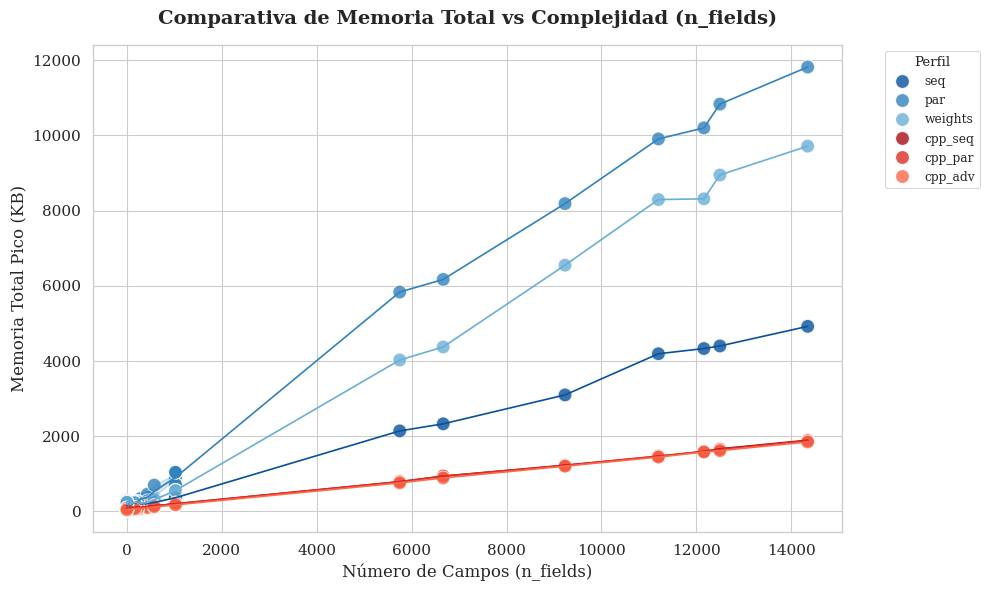

In [34]:
# Celda 10b: Relación de Complejidad (n_fields) vs Memoria Total (mem_total_kb)
import matplotlib.pyplot as plt
import seaborn as sns

paleta_perfiles = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='n_fields', y='mem_total_kb', hue='perfil', palette=paleta_perfiles, s=100, alpha=0.8, ax=ax)
sns.lineplot(data=df, x='n_fields', y='mem_total_kb', hue='perfil', palette=paleta_perfiles, legend=False, ax=ax)

ax.set_title('Comparativa de Memoria Total vs Complejidad (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Memoria Total Pico (KB)')
ax.set_xlabel('Número de Campos (n_fields)')

plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("complejidad_vs_memoria_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [13]:
df.describe()

,sample,n_nets,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
count,600.000000,600.0,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000
mean,50.500000,10.0,0.489170,0.015363,0.191307,0.696060,135.247656,14.836628,368.175439,460.327274,27.99000,35.770000,953.770000
std,28.890155,0.0,0.681386,0.021792,0.491550,0.914332,82.921740,16.897416,1337.236700,1318.003198,9.25379,29.621943,2701.090979
min,1.000000,10.0,0.001700,0.000038,0.000017,0.001794,21.187500,0.859375,0.000000,22.500000,19.00000,1.000000,0.000000
25%,25.750000,10.0,0.006481,0.000053,0.000127,0.010042,61.707031,1.308594,0.703125,74.660156,19.00000,11.750000,0.000000
50%,50.500000,10.0,0.161189,0.001188,0.009707,0.316261,116.263672,4.605957,32.311523,200.939941,29.00000,28.000000,1.000000
75%,75.250000,10.0,0.799849,0.038407,0.261194,1.110397,220.144531,37.346680,128.562500,234.681152,38.00000,68.000000,1024.000000
max,100.000000,10.0,5.794797,0.096116,4.503847,6.278377,544.858398,50.521484,11820.094727,11820.094727,48.00000,109.000000,14345.000000
